In [2]:
from google.colab import files
uploaded = files.upload()

Saving links.csv to links.csv
Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv
Saving README.txt to README.txt
Saving tags.csv to tags.csv


In [3]:
# ===============================
# MATRIX FACTORIZATION USING SVD
# ===============================
print("SUBASRI R 24BAD116")
import pandas as pd
import numpy as np
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Load dataset (ratings.csv from MovieLens)
df = pd.read_csv("ratings.csv")

# Create user-item matrix
user_item_matrix = df.pivot(index='userId', columns='movieId', values='rating')

# Fill missing values with 0
matrix_filled = user_item_matrix.fillna(0)

# Convert to numpy array
R = matrix_filled.values

# Mean centering
user_mean = np.mean(R, axis=1)
R_demeaned = R - user_mean.reshape(-1, 1)

# Apply SVD
k = 50  # number of latent factors
U, sigma, Vt = svds(R_demeaned, k=k)

# Convert sigma to diagonal matrix
sigma = np.diag(sigma)

# Reconstruct matrix
R_pred = np.dot(np.dot(U, sigma), Vt) + user_mean.reshape(-1, 1)

# Convert back to DataFrame
preds_df = pd.DataFrame(R_pred, columns=user_item_matrix.columns)

# Evaluation (RMSE, MAE)
actual = user_item_matrix.fillna(0).values.flatten()
predicted = preds_df.values.flatten()

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

# Function to recommend top N movies for a user
def recommend_movies(user_id, n=5):
    user_row = preds_df.iloc[user_id - 1]
    sorted_movies = user_row.sort_values(ascending=False)
    return sorted_movies.head(n)

# Example recommendation
print("Top Recommendations for User 1:")
print(recommend_movies(1))

SUBASRI R 24BAD116
RMSE: 0.3060225402291928
MAE: 0.0926898622468658
Top Recommendations for User 1:
movieId
1196    6.428209
260     6.338385
1210    6.035810
1291    6.017564
1198    5.991372
Name: 0, dtype: float64


In [9]:
# ===============================
# MATRIX FACTORIZATION USING NMF
# ===============================

import pandas as pd
import numpy as np
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ratings.csv")

# Create user-item matrix
user_item_matrix = df.pivot(index='userId', columns='movieId', values='rating')

# Fill missing values with 0
matrix_filled = user_item_matrix.fillna(0)

# Convert to numpy array
R = matrix_filled.values

# Apply NMF
k = 20  # number of latent features
model = NMF(n_components=k, init='random', random_state=42)

W = model.fit_transform(R)   # User-feature matrix
H = model.components_        # Item-feature matrix

# Reconstruct matrix
R_pred = np.dot(W, H)

# Convert to DataFrame
preds_df = pd.DataFrame(R_pred, columns=user_item_matrix.columns)

# Evaluation (RMSE)
rmse = np.sqrt(mean_squared_error(R.flatten(), R_pred.flatten()))
print("RMSE:", rmse)

# Function to recommend top N movies
def recommend_movies(user_id, n=5):
    user_row = preds_df.iloc[user_id - 1]
    sorted_movies = user_row.sort_values(ascending=False)
    return sorted_movies.head(n)

# Example
print("Top Recommendations for User 1:")
print(recommend_movies(1))

RMSE: 0.3594501132286364
Top Recommendations for User 1:
movieId
1196    5.342696
260     5.040761
1210    4.617175
1198    4.518504
589     4.459315
Name: 0, dtype: float64


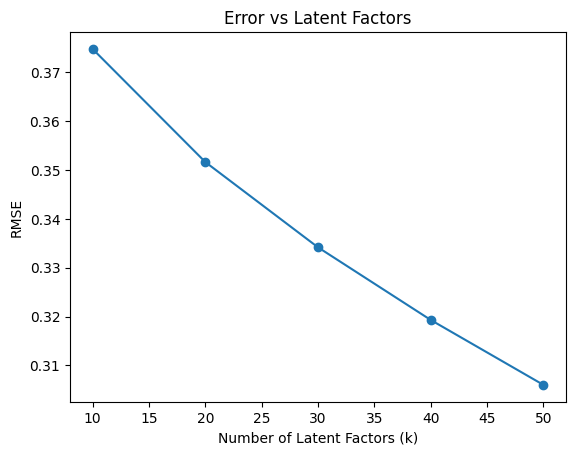

In [10]:
# Analyze effect of k on error (SVD example)

ks = [10, 20, 30, 40, 50]
errors = []

for k in ks:
    U, sigma, Vt = svds(R_demeaned, k=k)
    sigma = np.diag(sigma)
    R_pred = np.dot(np.dot(U, sigma), Vt) + user_mean.reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(R.flatten(), R_pred.flatten()))
    errors.append(rmse)

# Plot
plt.plot(ks, errors, marker='o')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

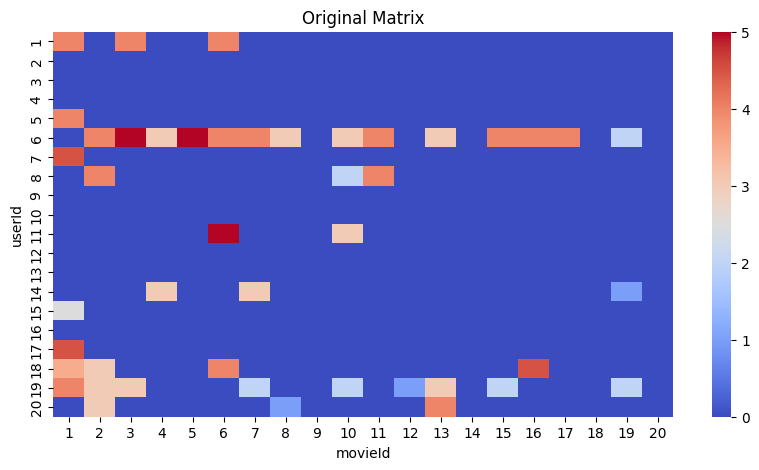

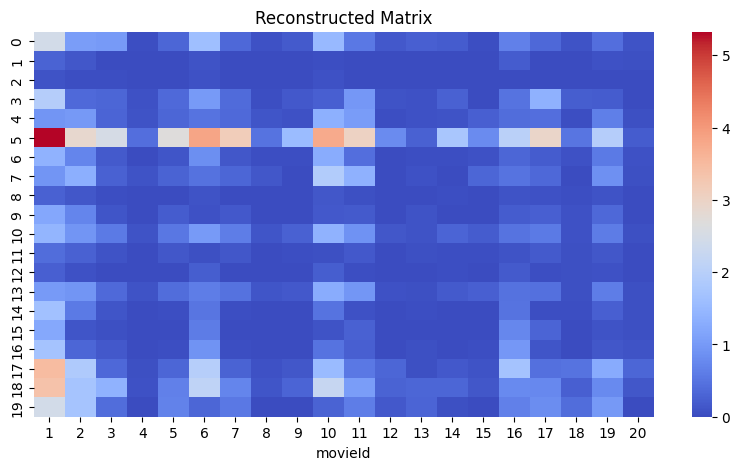

In [11]:
import seaborn as sns

# Original matrix
plt.figure(figsize=(10,5))
sns.heatmap(matrix_filled.iloc[:20, :20], cmap="coolwarm")
plt.title("Original Matrix")
plt.show()

# Reconstructed matrix
plt.figure(figsize=(10,5))
sns.heatmap(preds_df.iloc[:20, :20], cmap="coolwarm")
plt.title("Reconstructed Matrix")
plt.show()